# Морфологические операции и сегментация изображений

## 1. Бинаризация изображений

Бинаризация – это процесс преобразования градаций серого в **двухуровневое изображение** (обычно чёрно-белое), где пиксели принимают значения 0 или 255. Она используется для выделения объектов и упрощения дальнейшей обработки.

### Методы бинаризации:

1. **Глобальная пороговая обработка**

   * Применяется один фиксированный порог `T` для всего изображения:

     $$
     g(x,y) = \begin{cases}  
     0, & f(x,y) < T \\\\  
     255, & f(x,y) \geq T  
     \end{cases}
     $$
   * Подходит для изображений с равномерным освещением.

2. **Метод Отсу (Otsu’s method)**

   * Автоматически подбирает оптимальный порог так, чтобы минимизировать внутриклассовую дисперсию (разделяет гистограмму на два «кластера»).
   * Особенно полезен при неоднородной яркости.

3. **Адаптивная бинаризация**

   * Порог подбирается **локально** для каждой области изображения.
   * Применяется при неравномерном освещении, текстах или документах.

---

## 2. Морфологические операции

Морфологическая обработка изображений используется для анализа и модификации **формы объектов**. Применяется в основном к бинарным изображениям.

Основная идея: мы используем **структурирующий элемент** (kernel), чтобы трансформировать изображение.

### Базовые операции:

1. **Эрозия (Erosion)**

   * Уменьшает белые области (foreground).
   * «Съедает» границы объектов.
   * Применяется для удаления мелких шумов.

2. **Дилатация (Dilation)**

   * Расширяет белые области.
   * Утолщает объекты, заполняет пробелы.

### Составные операции:

3. **Открытие (Opening = Эрозия → Дилатация)**

   * Удаляет мелкие шумы.
   * Сохраняет форму крупных объектов.

4. **Закрытие (Closing = Дилатация → Эрозия)**

   * Заполняет мелкие «дыры» внутри объектов.
   * Сохраняет их размеры.

Эти операции широко применяются при подготовке масок для сегментации.

---

## 3. Сегментация изображений

Сегментация – это разбиение изображения на **однородные области** (объекты и фон). Она является важным шагом в распознавании изображений, так как выделяет области интереса для анализа.

### Методы сегментации:

1. **Пороговая сегментация**

   * Самый простой метод: применяем бинаризацию, чтобы отделить объект от фона.
   * Хорошо работает для контрастных изображений.

2. **Сегментация методом кластеризации (k-means)**

   * Изображение рассматривается как множество точек в цветовом пространстве.
   * Алгоритм разбивает пиксели на `k` кластеров (например, объект, фон, тень).
   * Подходит для цветных изображений.

3. **Алгоритм Watershed («водораздел»)**

   * Рассматривает изображение как топографическую карту (яркость = высота).
   * «Вода» заливает области от локальных минимумов; границы между ними становятся разделителями.
   * Хорошо разделяет соприкасающиеся объекты (например, монеты на столе).

---

## 4. Применение на практике

* **Бинаризация** → выделяем объекты от фона.
* **Морфология** → очищаем изображение от шумов, восстанавливаем форму объектов.
* **Сегментация** → делим изображение на объекты и фон.
* **Итог**: получаем маску объектов для дальнейшего анализа (подсчёт, распознавание, классификация).

---




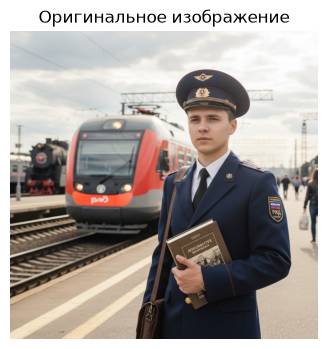

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Функция для удобного отображения изображений
def show_img(title, img, cmap=None):
    plt.figure(figsize=(4,4))
    plt.title(title)
    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


img = cv2.imread('example3.png')
show_img("Оригинальное изображение", img)

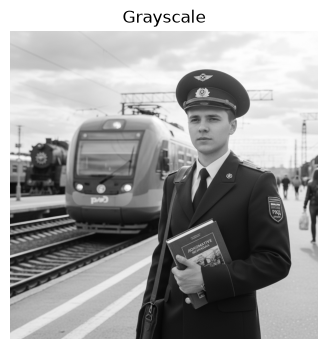

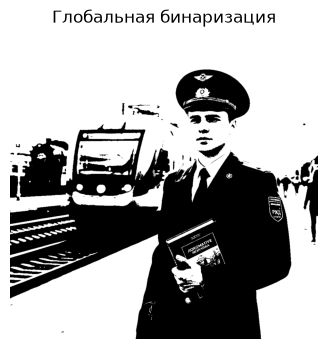

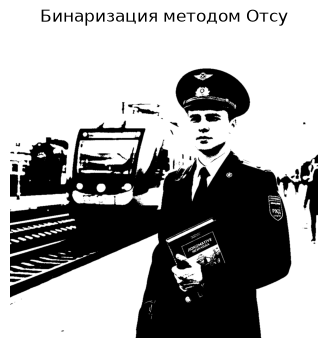

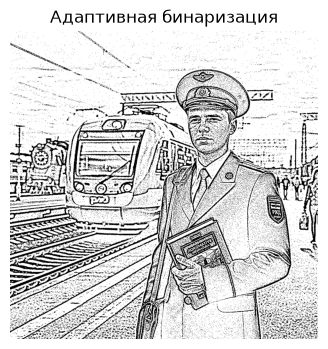

In [2]:
# --- Бинаризация изображений ---
# Переводим в grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_img("Grayscale", gray, cmap='gray')

# Глобальная бинаризация
_, thresh_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
show_img("Глобальная бинаризация", thresh_global, cmap='gray')

# Метод Отсу
_, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show_img("Бинаризация методом Отсу", thresh_otsu, cmap='gray')

# Адаптивная бинаризация
thresh_adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
show_img("Адаптивная бинаризация", thresh_adapt, cmap='gray')

In [3]:
cv2.threshold?

Docstring:
threshold(src, thresh, maxval, type[, dst]) -> retval, dst
.   @brief Applies a fixed-level threshold to each array element.
.   
.   The function applies fixed-level thresholding to a multiple-channel array. The function is typically
.   used to get a bi-level (binary) image out of a grayscale image ( #compare could be also used for
.   this purpose) or for removing a noise, that is, filtering out pixels with too small or too large
.   values. There are several types of thresholding supported by the function. They are determined by
.   type parameter.
.   
.   Also, the special values #THRESH_OTSU or #THRESH_TRIANGLE may be combined with one of the
.   above values. In these cases, the function determines the optimal threshold value using the Otsu's
.   or Triangle algorithm and uses it instead of the specified thresh.
.   
.   @note Currently, the Otsu's method is implemented only for CV_8UC1 and CV_16UC1 images,
.   and the Triangle's method is implemented only for CV_8UC

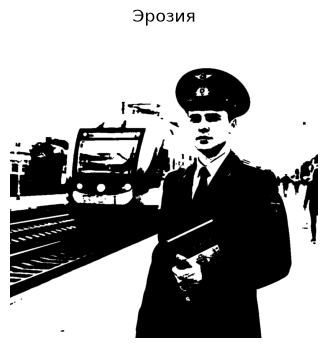

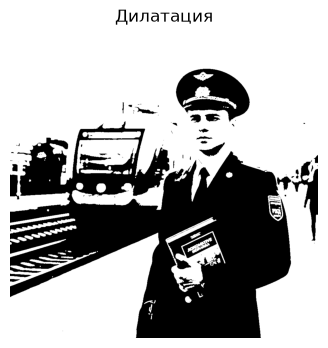

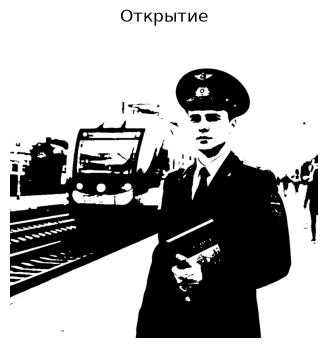

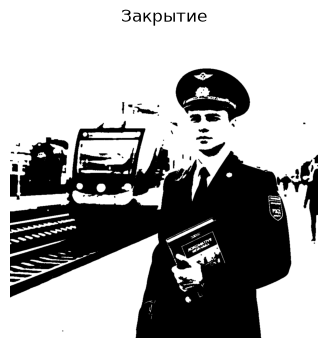

In [4]:
# --- Морфологические операции ---
kernel = np.ones((3,3), np.uint8)

# Эрозия
eroded = cv2.erode(thresh_otsu, kernel, iterations=1)
show_img("Эрозия", eroded, cmap='gray')

# Дилатация
dilated = cv2.dilate(thresh_otsu, kernel, iterations=1)
show_img("Дилатация", dilated, cmap='gray')

# Открытие (удаление шума)
opened = cv2.morphologyEx(thresh_otsu, cv2.MORPH_OPEN, kernel)
show_img("Открытие", opened, cmap='gray')

# Закрытие (заполнение дыр)
closed = cv2.morphologyEx(thresh_otsu, cv2.MORPH_CLOSE, kernel)
show_img("Закрытие", closed, cmap='gray')

https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html

Эрозия

    Удаление изолированного белого шума из изображения.
    Разделение объектов, которые соединяются или трогают.
    Нахождение границ объекта путем уменьшения размера объекта.

Дилатация

    Заполнение небольших отверстий или пробелов в объектах.
    Соединение сломанных или разъединенных частей одного и того же объекта.
    Используется после эрозии (в рамках операции «открытия») для восстановления размера объекта при удалении шума.

Эрозия и расширение являются фундаментальными морфологическими операциями в обработке изображений, которые позволяют нам совершенствовать, очищать и манипулировать формами в изображениях. Используя простые элементы структурирования, эти методы помогают удалять шум, разделять или соединять объекты и улучшать функции изображения, что делает их необходимыми инструментами для эффективной предварительной обработки и анализа задач компьютерного зрения с помощью OpenCV и Python.

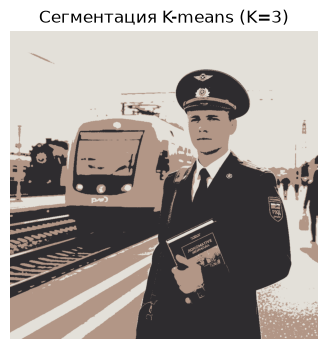

In [5]:
# --- Сегментация объектов ---
# 1. Сегментация методом K-means
Z = img.reshape((-1,3))
Z = np.float32(Z)

# критерий и запуск k-means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

K = 3 # количество кластеров
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
res = centers[labels.flatten()]
segmented_kmeans = res.reshape((img.shape))
show_img("Сегментация K-means (K=3)", segmented_kmeans)

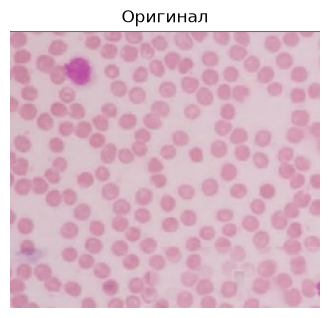

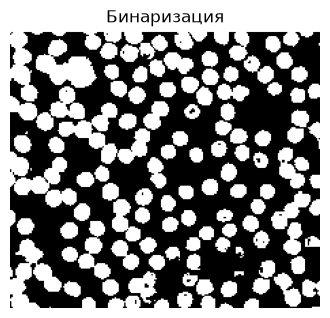

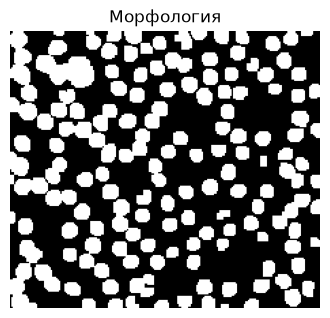

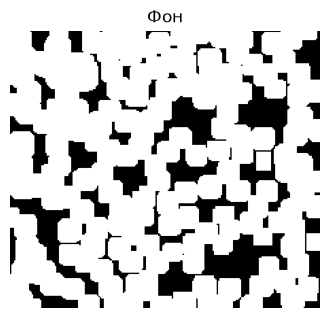

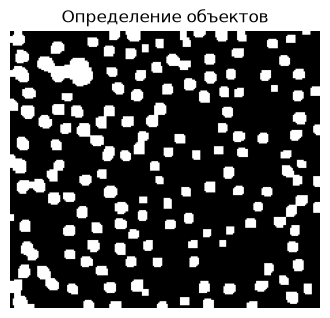

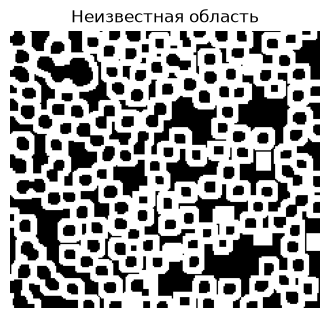

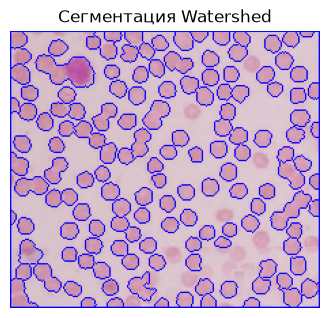

In [6]:
#https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html

# img = cv2.imread('water_coins.jpg')
img = cv2.imread('eritrozits_mikroskops.png')
show_img("Оригинал", img)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Сегментация методом Watershed
# Бинаризация
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
show_img("Бинаризация", binary, cmap='gray')

# Морфология (убираем шумы)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
show_img("Морфология", opening, cmap='gray')

# Фон
sure_bg = cv2.dilate(opening, kernel, iterations=3)
show_img("Фон", sure_bg, cmap='gray')

# Определение объектов
sure_fg = cv2.erode(binary, kernel, iterations=3)
sure_fg = cv2.dilate(sure_fg, kernel, iterations=2)
show_img("Определение объектов", sure_fg, cmap='gray')

# Distance Transform для выделения центров
#dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
#_, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
#show_img("Distance Transform", sure_fg, cmap='gray')

# Неизвестная область
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
show_img("Неизвестная область", unknown, cmap='gray')

# Маркеры
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0

# Watershed
img_w = img.copy()
markers = cv2.watershed(img_w, markers)
img_w[markers == -1] = [255,0,0]

show_img("Сегментация Watershed", img_w)


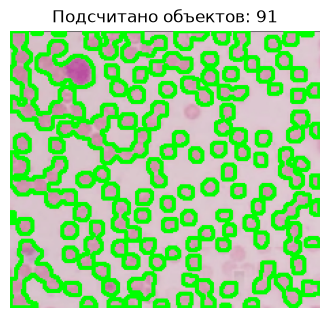

In [7]:
# --- Мини-проект: Подсчет объектов (монеты) ---
# Используем бинаризацию + морфологию + поиск контуров
blur = cv2.GaussianBlur(gray, (5,5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

# Морфология для очистки
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# Поиск контуров
contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
result = img.copy()
cv2.drawContours(result, contours, -1, (0,255,0), 2)

show_img(f"Подсчитано объектов: {len(contours)}", result)


Интересная статья по теме: https://habr.com/ru/articles/786436/

## 🔧 Подходы к улучшению распознавания контуров

### 1. Использовать **морфологическое открытие и закрытие**

* Убираем мелкий шум (открытие).
* Закрываем маленькие разрывы в границах (закрытие).
  Это помогает «разъединить» касающиеся объекты.

```python
kernel = np.ones((3,3), np.uint8)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)
```

---

### 2. Применить **дистанционное преобразование + Watershed**

Когда объекты касаются, можно выделить их центры с помощью distance transform, а потом разделить:

```python
# Distance transform
dist = cv2.distanceTransform(opened, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5*dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Фон
sure_bg = cv2.dilate(opened, kernel, iterations=3)

# Неизвестная область
unknown = cv2.subtract(sure_bg, sure_fg)

# Маркеры
_, markers = cv2.connectedComponents(sure_fg)
markers = markers+1
markers[unknown==255] = 0

# Watershed
img_ws = img.copy()
markers = cv2.watershed(img_ws, markers)
img_ws[markers == -1] = [255,0,0]
```

После этого касающиеся объекты будут разделены линиями водораздела.

---

### 3. Использовать **контурный анализ**

Иногда помогает дополнительная фильтрация по:

* площади (`cv2.contourArea`)
* соотношению сторон ограничивающего прямоугольника
* круглости (`4πS / P²`)

Можно отфильтровать ложные слияния.

---

### 4. Применить **адаптивный порог**

Иногда слияние вызвано неравномерным освещением. В этом случае помогает:

```python
adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 11, 2)
```

---

✅ **Рекомендация для студентов:**
Показать на практике, как один и тот же набор монет можно сегментировать по-разному:

* только бинаризация + контуры (слипшиеся монеты → ошибка),
* бинаризация + морфология,
* бинаризация + distance transform + watershed (лучшее разделение).

---


## Индивидуальные задания

### Собственное изображение (монеты)

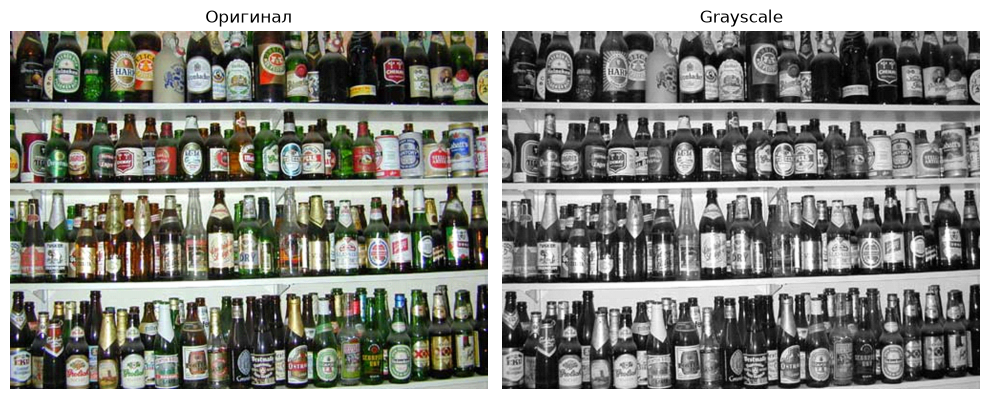

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show(images, titles, cmap="gray", figsize=(16, 4)):
    fig, ax = plt.subplots(1, len(images), figsize=figsize)
    for a, im, t in zip(ax, images, titles):
        if len(im.shape) == 2:
            a.imshow(im, cmap=cmap)
        else:
            a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


img = cv2.imread("image.png")
if img is None:
    raise FileNotFoundError("Не удалось прочитать: water_coins.jpg")

scale = 2
img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape[:2]

show([img, gray], ["Оригинал", "Grayscale"], figsize=(10, 4))


### Бинаризация (глобальный порог / Отсу / адаптивная)

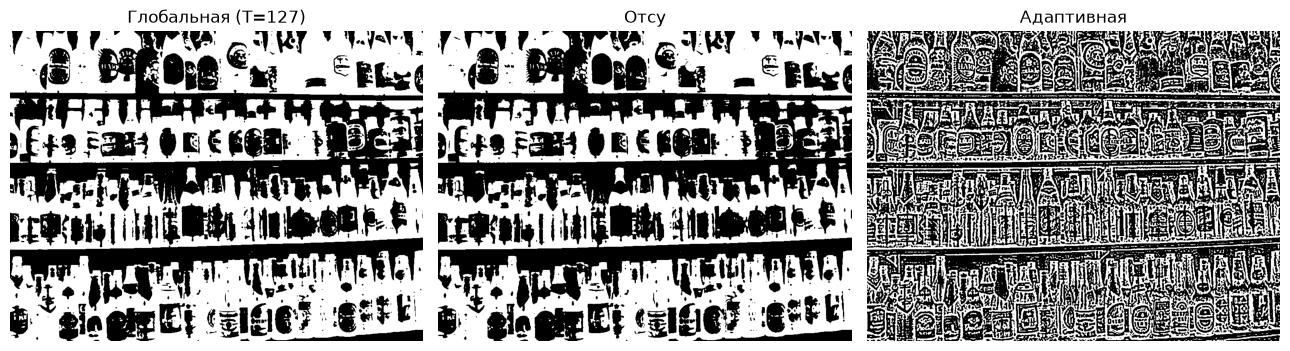

In [9]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, th_global = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)
_, th_otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
th_adapt = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 11, 2)

show([th_global, th_otsu, th_adapt],
     ["Глобальная (T=127)", "Отсу", "Адаптивная"], figsize=(13, 4))


### Морфологические операции

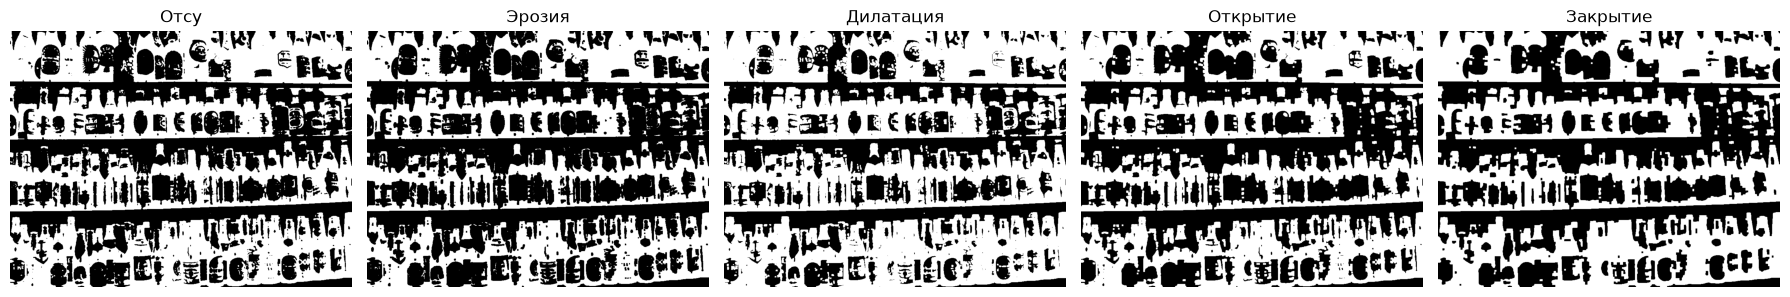

In [10]:
kernel = np.ones((3, 3), np.uint8)

eroded = cv2.erode(th_otsu, kernel, iterations=1)
dilated = cv2.dilate(th_otsu, kernel, iterations=1)
opened = cv2.morphologyEx(th_otsu, cv2.MORPH_OPEN, kernel, iterations=2)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

show([th_otsu, eroded, dilated, opened, closed],
     ["Отсу", "Эрозия", "Дилатация", "Открытие", "Закрытие"], figsize=(18, 4))


### Способ 1: бинаризация + контуры (слипшиеся монеты → ошибка)

Контуров найдено: 206


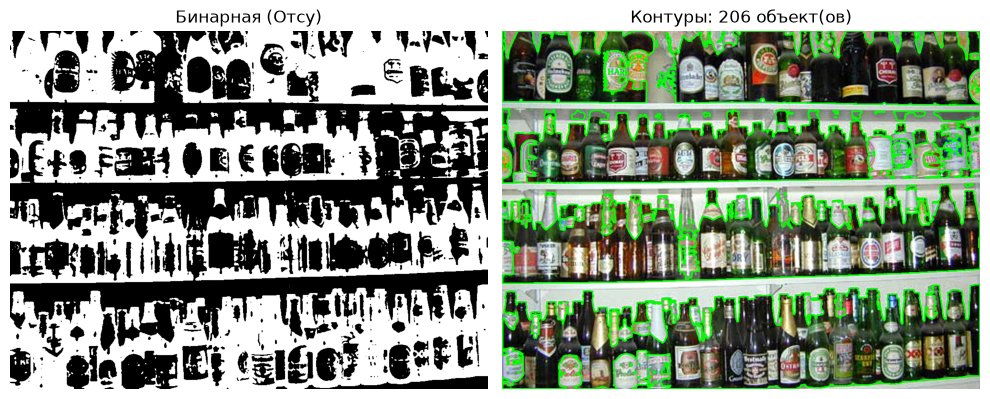

In [11]:
contours, _ = cv2.findContours(th_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
res = img.copy()
cv2.drawContours(res, contours, -1, (0, 255, 0), 2)
print(f"Контуров найдено: {len(contours)}")

show([th_otsu, res],
     ["Бинарная (Отсу)", f"Контуры: {len(contours)} объект(ов)"], figsize=(10, 4))


### Способ 2: бинаризация + морфология + контуры

Контуров найдено: 73


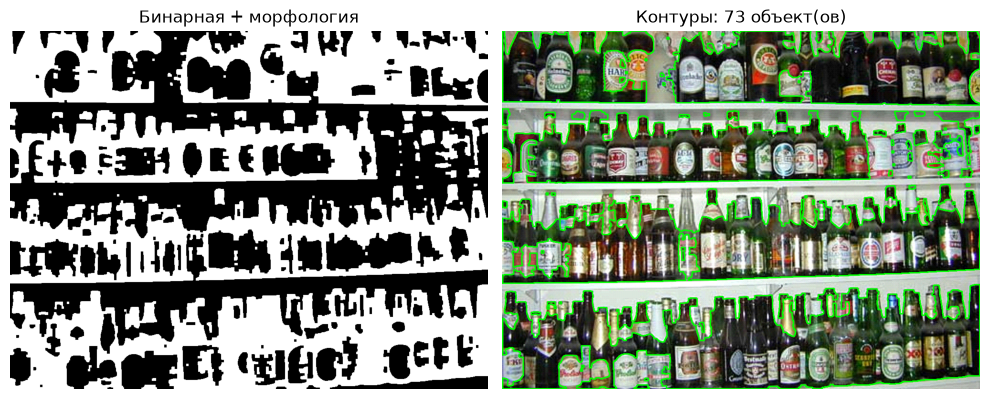

In [12]:
opened = cv2.morphologyEx(th_otsu, cv2.MORPH_OPEN, kernel, iterations=2)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
res = img.copy()
cv2.drawContours(res, contours, -1, (0, 255, 0), 2)
print(f"Контуров найдено: {len(contours)}")

show([closed, res],
     ["Бинарная + морфология", f"Контуры: {len(contours)} объект(ов)"], figsize=(10, 4))


### Способ 3: бинаризация + distance transform + watershed

Объектов после watershed: 31


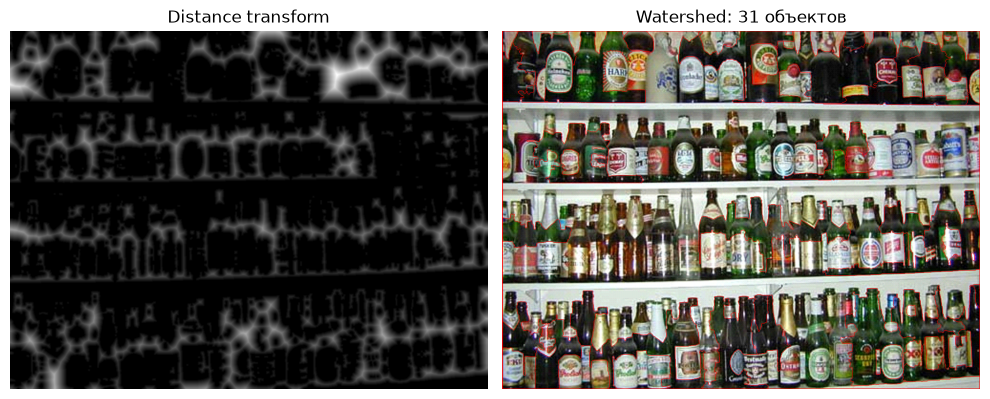

In [13]:
sure_bg = cv2.dilate(opened, kernel, iterations=3)

dist = cv2.distanceTransform(opened, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

res = img.copy()
markers = cv2.watershed(res, markers)
res[markers == -1] = [0, 0, 255]

count = sum(1 for r in np.unique(markers) if r >= 2 and np.sum(markers == r) > 400)
print(f"Объектов после watershed: {count}")

show([dist, res],
     ["Distance transform", f"Watershed: {count} объектов"], figsize=(10, 4))


### Вывод (какой способ лучше сегментирует объекты)

Способ 1 (бинаризация + контуры): 2 контура — монеты **слиплись**, подсчёт неверный.

Способ 2 (+ морфология): 1 объект — морфология убирает шум, но не разделяет соседние монеты.

Способ 3 (distance transform + watershed): 24 объекта — касающиеся монеты разделены по «водоразделу».

Лучший результат даёт **watershed**: он корректно разделяет даже касающиеся объекты.


### (Доп) Сегментация по цвету (K-means)

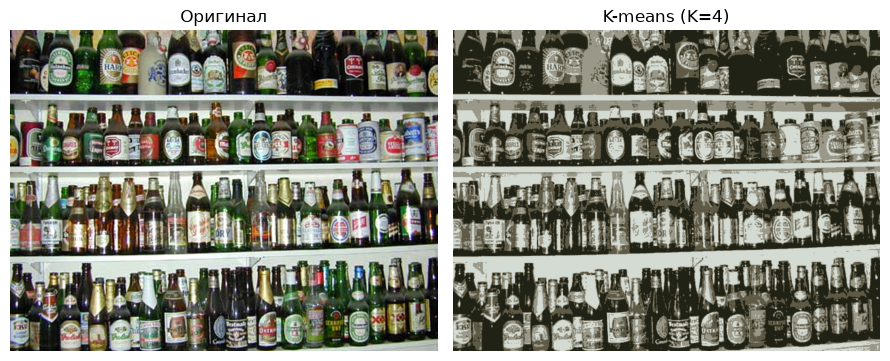

In [14]:
Z = img.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, 4, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
seg_kmeans = centers[labels.flatten()].reshape(img.shape)
show([img, seg_kmeans], ["Оригинал", "K-means (K=4)"], figsize=(9, 4))


### (Доп) Чувствительность watershed к порогу distance transform

In [15]:
for frac in [0.3, 0.5, 0.7]:
    _, sf = cv2.threshold(dist, frac * dist.max(), 255, 0)
    sf = np.uint8(sf)
    unk = cv2.subtract(sure_bg, sf)
    _, m = cv2.connectedComponents(sf)
    m = m + 1
    m[unk == 255] = 0
    wm = cv2.watershed(img, m)
    n = sum(1 for r in np.unique(wm) if r >= 2 and np.sum(wm == r) > 400)
    print(f"  порог {frac:.1f}*max -> {n} объектов")


  порог 0.3*max -> 107 объектов
  порог 0.5*max -> 31 объектов
  порог 0.7*max -> 3 объектов


## Улучшения качества распознования

### 0. Исходное изображение и бинаризация

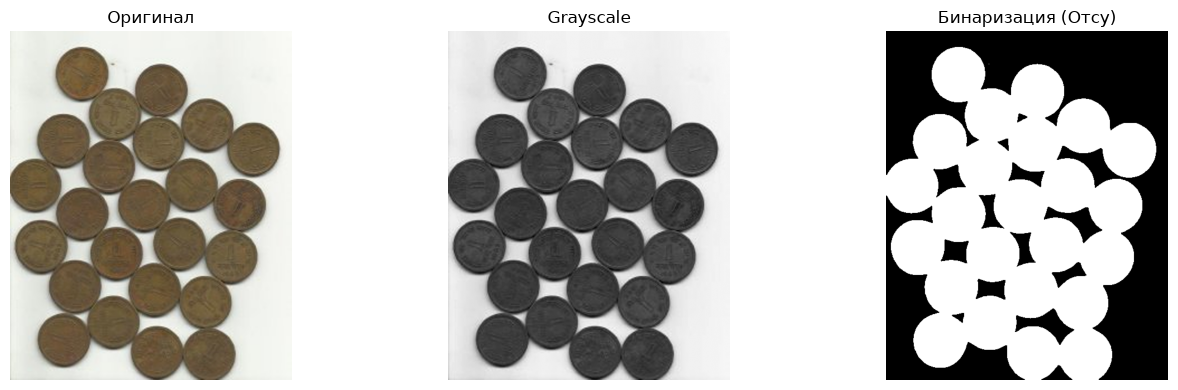

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show(images, titles, cmap="gray", figsize=(16, 4)):
    fig, ax = plt.subplots(1, len(images), figsize=figsize)
    for a, im, t in zip(ax, images, titles):
        if len(im.shape) == 2:
            a.imshow(im, cmap=cmap)
        else:
            a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


img = cv2.imread("water_coins.jpg")
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
show([img, gray, binary], ["Оригинал", "Grayscale", "Бинаризация (Отсу)"], figsize=(14, 4))


### 1. Морфологическое открытие и закрытие

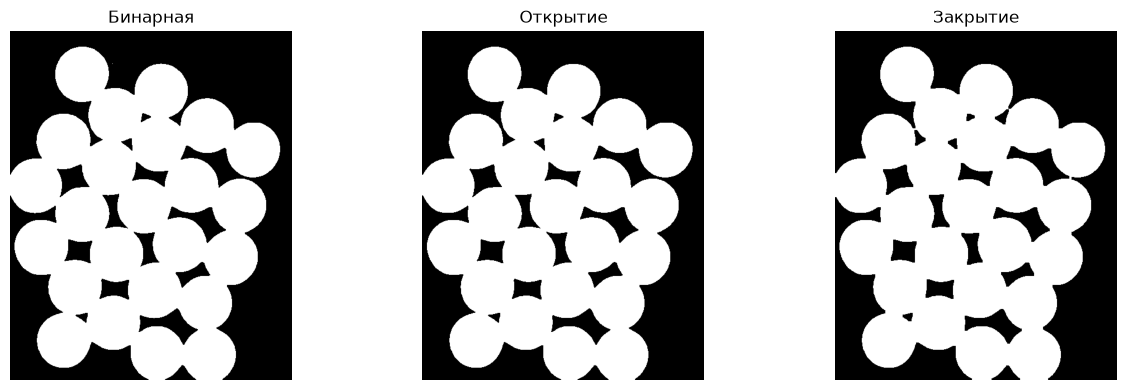

In [17]:
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)
show([binary, opened, closed], ["Бинарная", "Открытие", "Закрытие"], figsize=(13, 4))


### 2. Дистанционное преобразование + Watershed

Объектов после watershed: 24


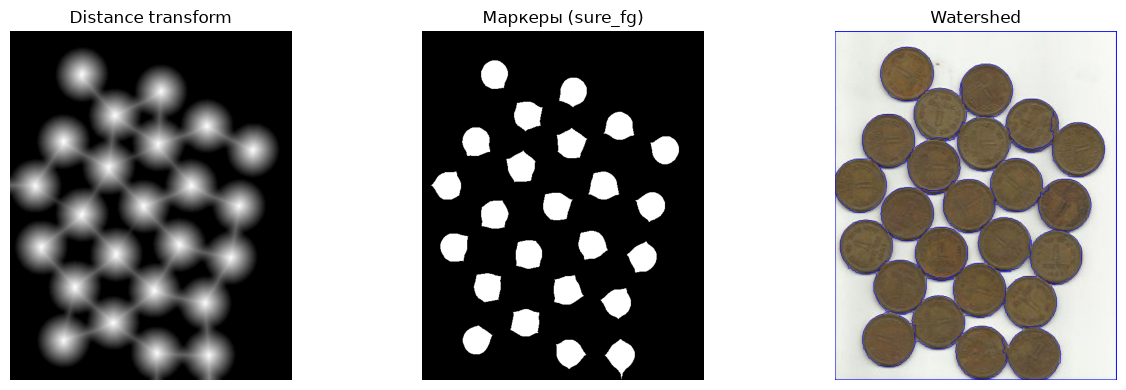

In [18]:
sure_bg = cv2.dilate(opened, kernel, iterations=3)

dist = cv2.distanceTransform(opened, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

img_ws = img.copy()
markers = cv2.watershed(img_ws, markers)
img_ws[markers == -1] = [255, 0, 0]

count_ws = sum(1 for r in np.unique(markers) if r >= 2 and np.sum(markers == r) > 400)
print(f"Объектов после watershed: {count_ws}")

show([dist, sure_fg, img_ws],
     ["Distance transform", "Маркеры (sure_fg)", "Watershed"], figsize=(13, 4))


### 3. Контурный анализ (площадь, круглость)

После фильтрации по площади S>400 оставлено: 24
  S=  1836  круглость=0.82
  S=  1937  круглость=0.66
  S=  1862  круглость=0.84
  S=  1940  круглость=0.76
  S=  1887  круглость=0.79


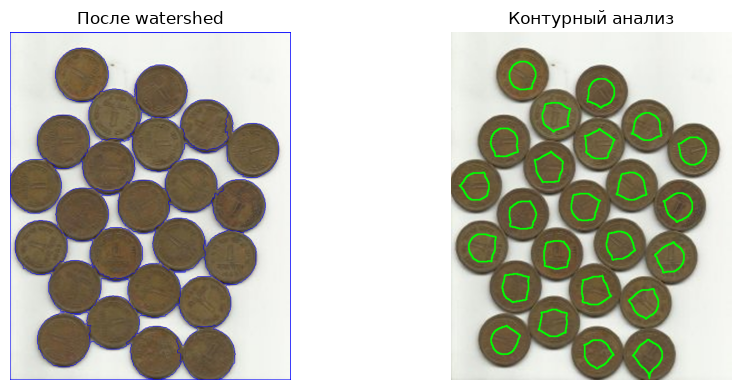

In [19]:
contours, _ = cv2.findContours(sure_fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

good = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 400:
        continue
    peri = cv2.arcLength(cnt, True)
    circ = 4 * np.pi * area / (peri * peri) if peri else 0
    good.append((cnt, area, circ))

res = img.copy()
cv2.drawContours(res, [g[0] for g in good], -1, (0, 255, 0), 2)
print(f"После фильтрации по площади S>400 оставлено: {len(good)}")
for cnt, area, circ in good[:5]:
    print(f"  S={area:6.0f}  круглость={circ:.2f}")

show([img_ws, res], ["После watershed", "Контурный анализ"], figsize=(10, 4))


### 4. Адаптивный порог при неравномерном освещении

## Обработка собственного изображения (text.png)

### 1. Бинаризация

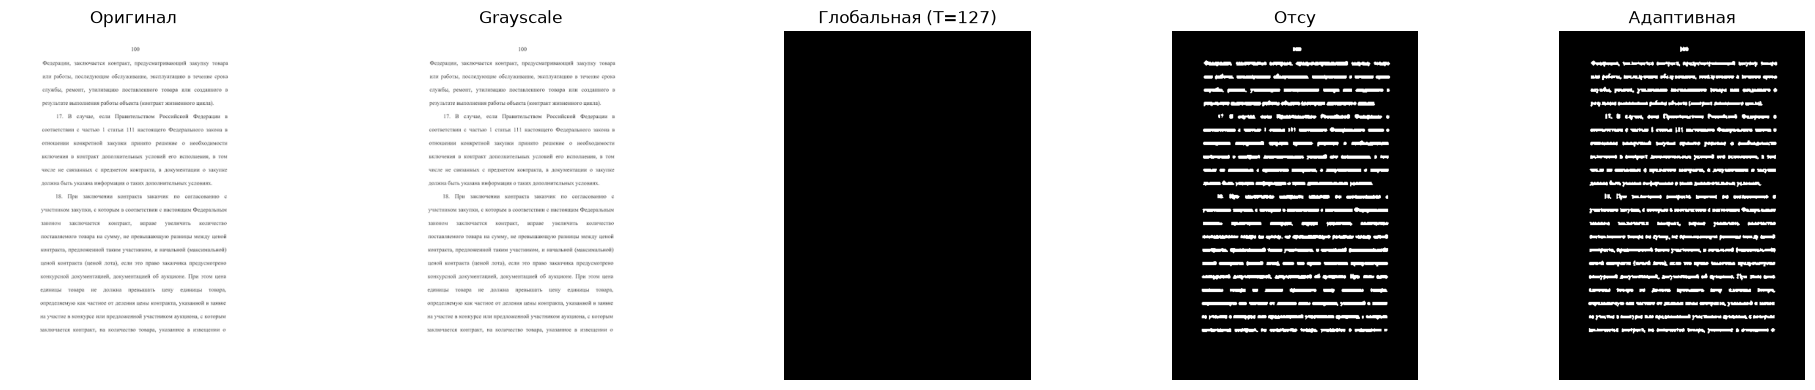

In [20]:
img = cv2.imread("text.png")
if img is None:
    raise FileNotFoundError("Не удалось прочитать: text.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, th_global = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)
_, th_otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
th_adapt = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 11, 2)

show([img, gray, th_global, th_otsu, th_adapt],
     ["Оригинал", "Grayscale", "Глобальная (T=127)", "Отсу", "Адаптивная"],
     figsize=(20, 4))


### 2. Морфологические операции

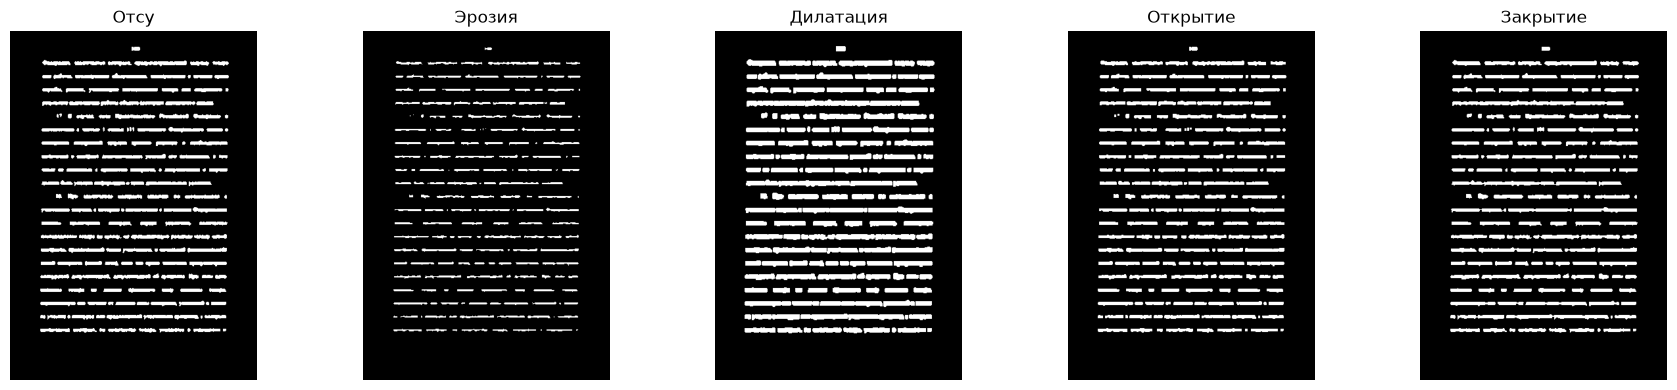

In [21]:
eroded = cv2.erode(th_otsu, kernel, iterations=1)
dilated = cv2.dilate(th_otsu, kernel, iterations=1)
opened = cv2.morphologyEx(th_otsu, cv2.MORPH_OPEN, kernel, iterations=1)
closed = cv2.morphologyEx(th_otsu, cv2.MORPH_CLOSE, kernel, iterations=1)

show([th_otsu, eroded, dilated, opened, closed],
     ["Отсу", "Эрозия", "Дилатация", "Открытие", "Закрытие"], figsize=(18, 4))


### 3. Сегментация (Watershed)

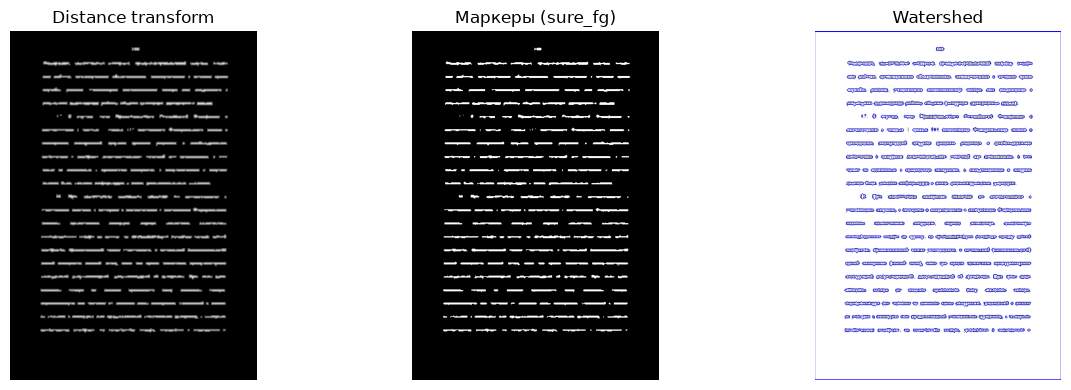

In [22]:
sure_bg = cv2.dilate(opened, kernel, iterations=3)
dist = cv2.distanceTransform(opened, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

img_ws = img.copy()
markers = cv2.watershed(img_ws, markers)
img_ws[markers == -1] = [255, 0, 0]
show([dist, sure_fg, img_ws],
     ["Distance transform", "Маркеры (sure_fg)", "Watershed"], figsize=(13, 4))


### 4. Контурный анализ / подсчёт объектов

Контуров всего: 177, после фильтра S>50: 134


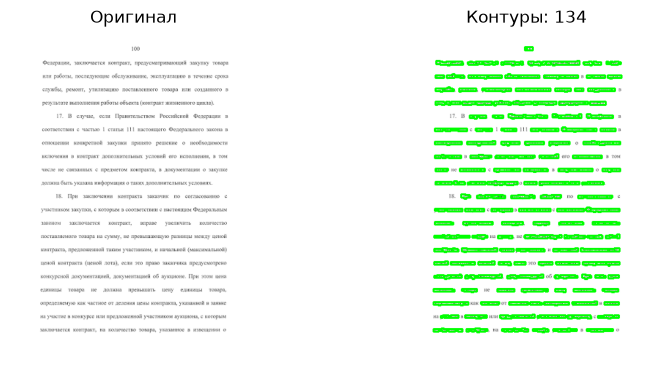

In [23]:
contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

good = [c for c in contours if cv2.contourArea(c) > 50]
res = img.copy()
cv2.drawContours(res, good, -1, (0, 255, 0), 2)
print(f"Контуров всего: {len(contours)}, после фильтра S>50: {len(good)}")

show([img, res], ["Оригинал", f"Контуры: {len(good)}"], figsize=(9, 4))
